## Min-Max Scaling

In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git

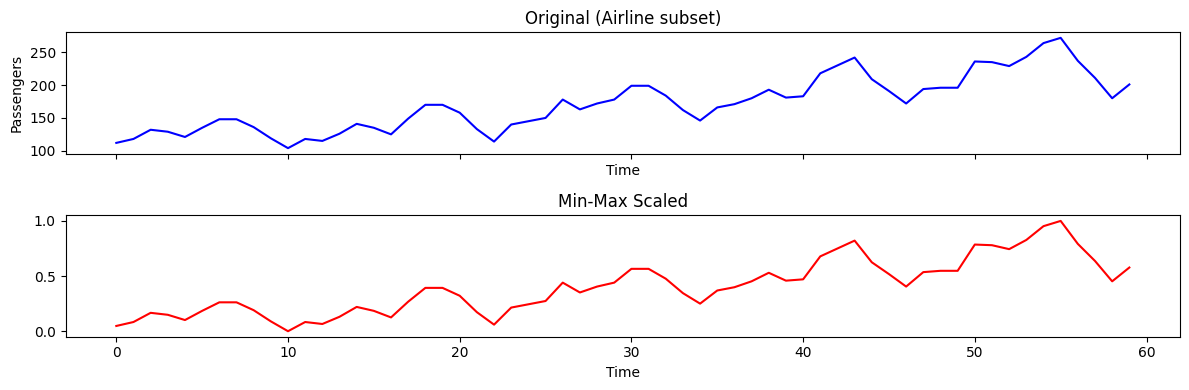

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sktime.datasets import load_airline

y = load_airline().values
y_segment = y[:60]

scaler = MinMaxScaler()
y_minmax = scaler.fit_transform(y_segment.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(y_segment, color="blue")
axes[0].set_title("Original (Airline subset)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Passengers")
axes[1].plot(y_minmax, color="red")
axes[1].set_title("Min-Max Scaled")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Standard Scaling

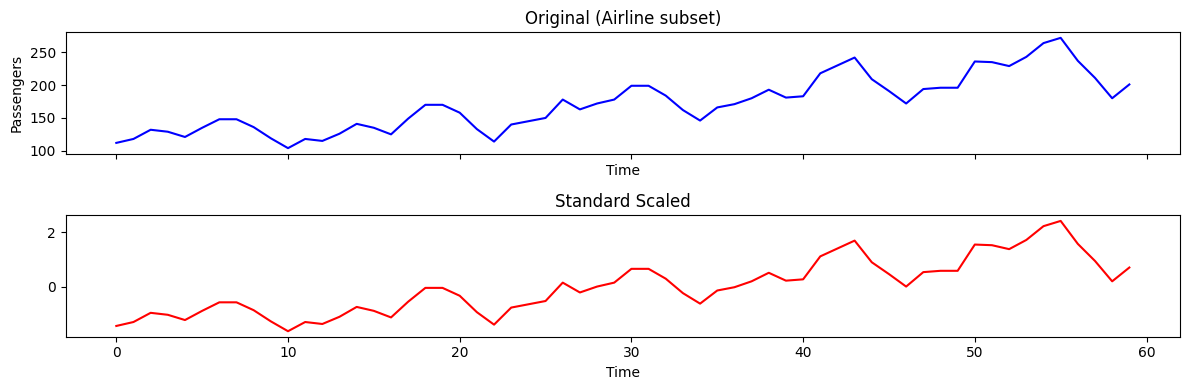

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sktime.datasets import load_airline

y = load_airline().values
y_segment = y[:60]

scaler = StandardScaler()
y_standard = scaler.fit_transform(y_segment.reshape(-1, 1)).ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(y_segment, color="blue")
axes[0].set_title("Original (Airline subset)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Passengers")
axes[1].plot(y_standard, color="red")
axes[1].set_title("Standard Scaled")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## L2 Normalizing

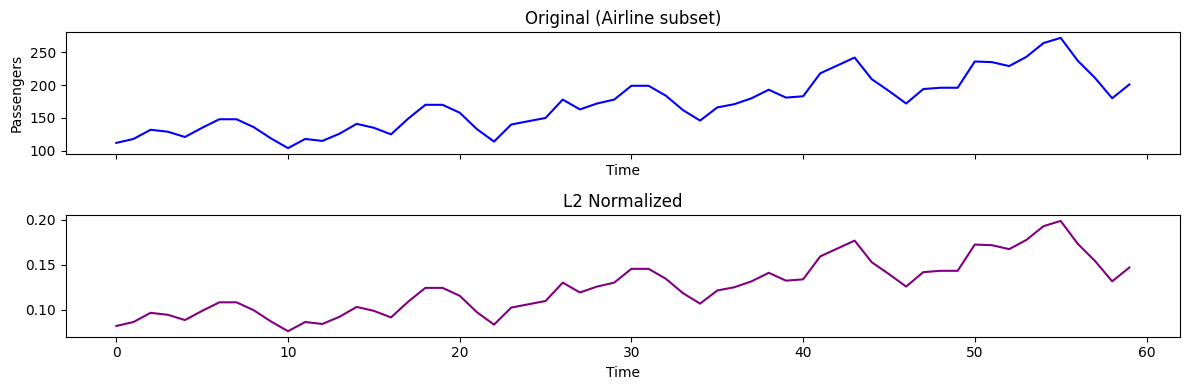

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_airline

def l2_normalize(arr):
    norm = np.linalg.norm(arr)
    return arr / norm if norm != 0 else arr

y = load_airline().values
y_segment = y[:60]
y_l2 = l2_normalize(y_segment)

fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(y_segment, color="blue")
axes[0].set_title("Original (Airline subset)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Passengers")
axes[1].plot(y_l2, color="purple")
axes[1].set_title("L2 Normalized")
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Smoothing

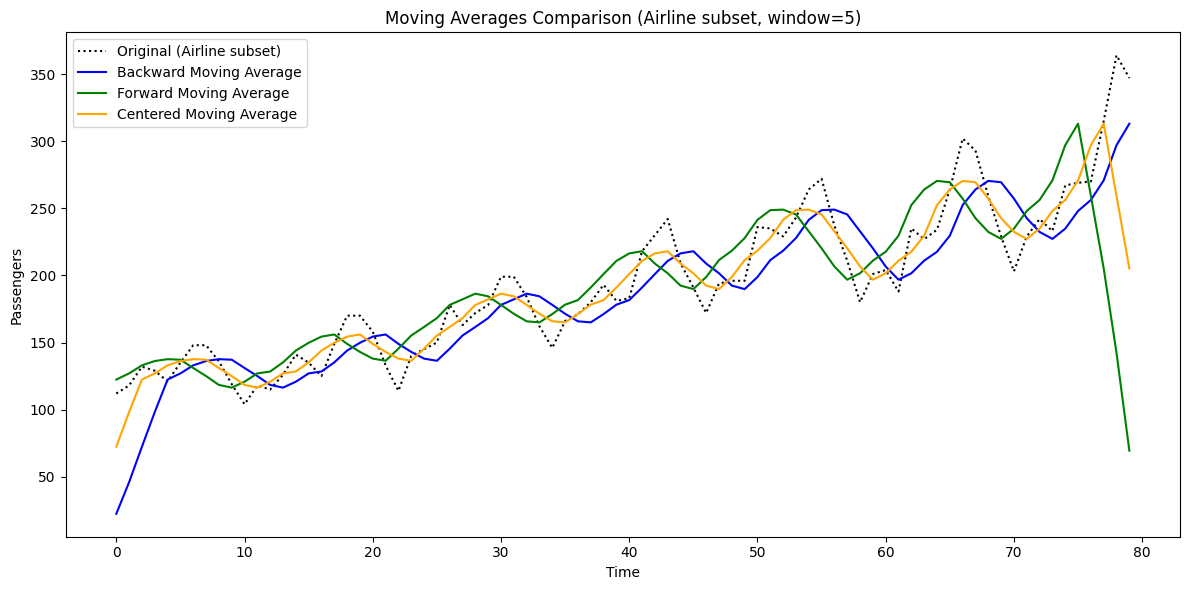

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sktime.datasets import load_airline

y = load_airline().values
y_segment = y[:80]

def backward_moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode="full")[: len(data)]

def forward_moving_average(data, window_size):
    return np.convolve(data[::-1], np.ones(window_size) / window_size, mode="full")[: len(data)][::-1]

def centered_moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode="same")

window_size = 5
backward_avg = backward_moving_average(y_segment, window_size)
forward_avg = forward_moving_average(y_segment, window_size)
centered_avg = centered_moving_average(y_segment, window_size)

plt.figure(figsize=(12, 6))
plt.plot(y_segment, label="Original (Airline subset)", color="black", linestyle="dotted")
plt.plot(backward_avg, label="Backward Moving Average", color="blue")
plt.plot(forward_avg, label="Forward Moving Average", color="green")
plt.plot(centered_avg, label="Centered Moving Average", color="orange")
plt.title("Moving Averages Comparison (Airline subset, window=5)")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

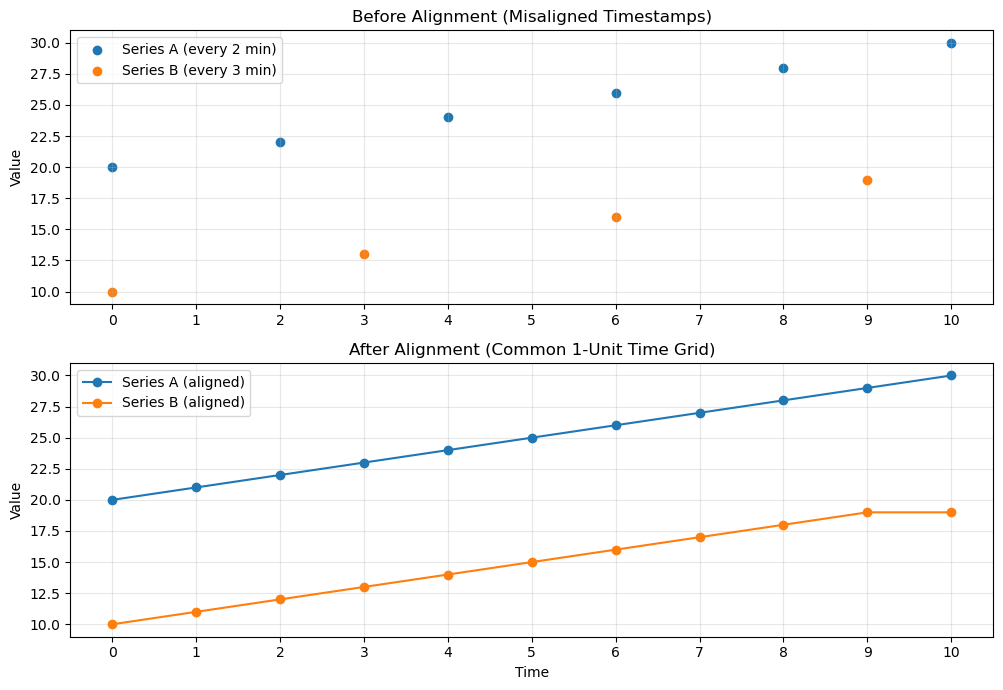

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define common time grid
grid = np.arange(0, 11, 1)

# Irregular sampling timestamps
A_time = np.array([0, 2, 4, 6, 8, 10])
B_time = np.array([0, 3, 6, 9])

# Example values (designed to avoid crossing)
A_values = np.array([20, 22, 24, 26, 28, 30])
B_values = np.array([10, 13, 16, 19])

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# -------------------
# BEFORE ALIGNMENT
# -------------------
axes[0].scatter(A_time, A_values, marker='o', label="Series A (every 2 min)")
axes[0].scatter(B_time, B_values, marker='o', label="Series B (every 3 min)")

axes[0].set_title("Before Alignment (Misaligned Timestamps)")
axes[0].set_ylabel("Value")
axes[0].set_xticks(grid)
axes[0].tick_params(labelbottom=True)  # Show x-axis labels on top subplot
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# -------------------
# AFTER ALIGNMENT
# -------------------
A_aligned = np.interp(grid, A_time, A_values)
B_aligned = np.interp(grid, B_time, B_values)

axes[1].plot(grid, A_aligned, marker='o', label="Series A (aligned)")
axes[1].plot(grid, B_aligned, marker='o', label="Series B (aligned)")

axes[1].set_title("After Alignment (Common 1-Unit Time Grid)")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")
axes[1].set_xticks(grid)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

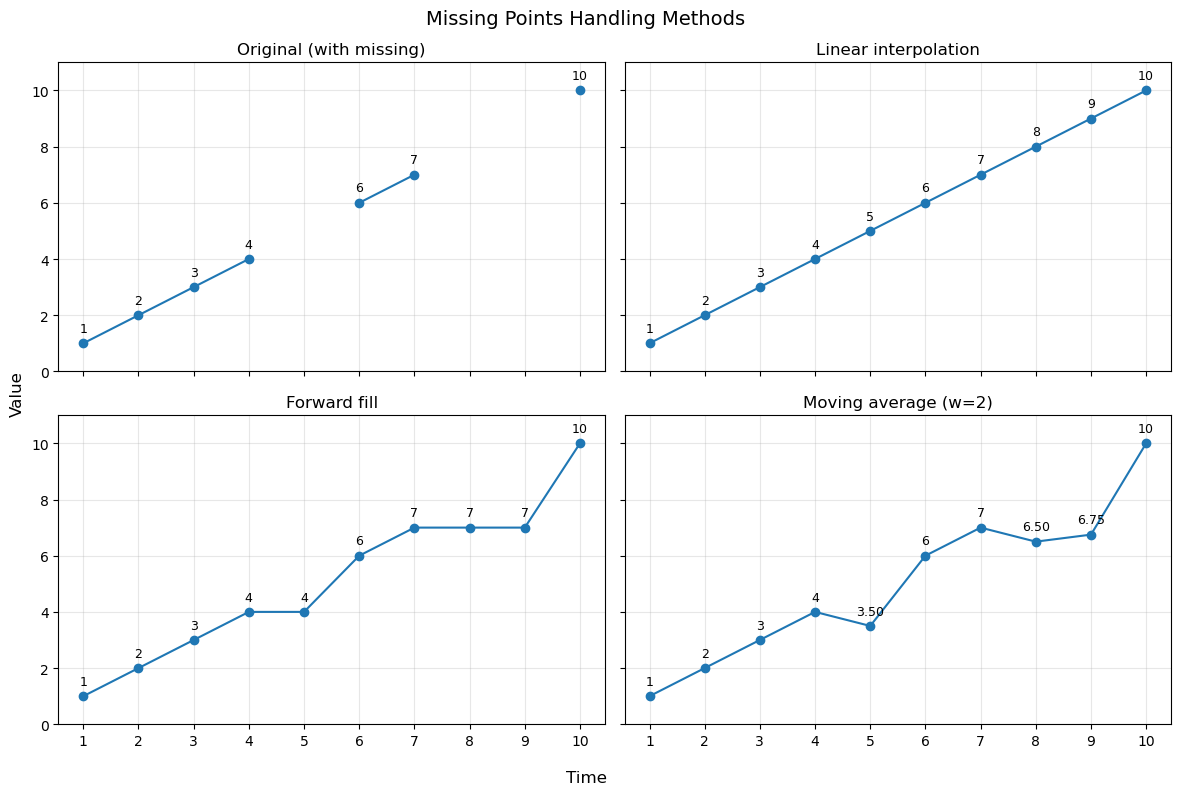

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Time index
x = np.arange(1, 11)

# Original series with missing values
original = np.array([1, 2, 3, 4, np.nan, 6, 7, np.nan, np.nan, 10], dtype=float)

# ---------------------------
# Linear interpolation
# ---------------------------
linear_interp = original.copy()
n = len(linear_interp)

i = 0
while i < n:
    if not np.isnan(linear_interp[i]):
        i += 1
        continue

    start = i
    while i < n and np.isnan(linear_interp[i]):
        i += 1
    end = i - 1

    left = start - 1
    right = i

    if left >= 0 and right < n:
        gap = right - left
        for k in range(1, gap):
            linear_interp[left + k] = (
                linear_interp[left]
                + (linear_interp[right] - linear_interp[left]) * (k / gap)
            )

# ---------------------------
# Forward fill
# ---------------------------
forward_fill = original.copy()
last_val = np.nan
for i in range(len(forward_fill)):
    if np.isnan(forward_fill[i]):
        forward_fill[i] = last_val
    else:
        last_val = forward_fill[i]

# ---------------------------
# Moving average fill (w=5)
# trailing recursive version
# ---------------------------
window = 2
moving_avg = original.copy()

for i in range(len(moving_avg)):
    if not np.isnan(moving_avg[i]):
        continue

    prev_vals = moving_avg[:i]
    prev_vals = prev_vals[~np.isnan(prev_vals)]

    if len(prev_vals) == 0:
        continue

    k = min(window, len(prev_vals))
    moving_avg[i] = np.mean(prev_vals[-k:])

# ---------------------------
# Plotting
# ---------------------------
series = [
    ("Original (with missing)", original),
    ("Linear interpolation", linear_interp),
    ("Forward fill", forward_fill),
    (f"Moving average (w={window})", moving_avg),
]

def annotate_points(ax, xs, ys):
    for xi, yi in zip(xs, ys):
        if np.isnan(yi):
            continue
        is_int = abs(yi - round(yi)) < 1e-9
        label = str(int(round(yi))) if is_int else f"{yi:.2f}"
        ax.annotate(
            label,
            (xi, yi),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            va="bottom",
            fontsize=9
        )

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (title, y) in zip(axes, series):
    ax.plot(x, y, marker="o")
    annotate_points(ax, x, y)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3)

fig.supxlabel("Time")
fig.supylabel("Value")
fig.suptitle("Missing Points Handling Methods", fontsize=14)

plt.tight_layout()
plt.show()